In [245]:
import requests
from datetime import datetime
from dateutil.relativedelta import relativedelta
import torch.nn
import pandas
import numpy
import torch.nn.functional
from torch.autograd import Variable
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
import yfinance
import matplotlib.pyplot as plt
import requests
from datetime import datetime
from dateutil.relativedelta import relativedelta
import warnings
warnings.filterwarnings(action='ignore')
## Prepare Data set
warnings.filterwarnings(action='ignore')
pandas.set_option('display.float_format', '{:.4f}'.format)

In [120]:
loan_data=pandas.read_csv('/Users/kbh/Downloads/lending club/all_clean_current_final_out_data.csv')
loan_data['issue_d'].dropna(inplace=True)
loan_data['target']=loan_data['total_rec_prncp']/loan_data['funded_amnt']
def clean_data(x) :
    x.replace([numpy.inf],0,inplace=True)
    x.replace([numpy.NAN],0,inplace=True)
clean_data(loan_data)

In [4]:
def clean_data(x) :
    x.replace([numpy.inf],0,inplace=True)
    x.replace([numpy.NAN],0,inplace=True)
y_temp=loan_data['total_rec_prncp']/loan_data['funded_amnt']
clean_data(y_temp)
id=loan_data['id']
loan_data.drop('id',axis=1,inplace=True)
select_feature='''
loan_amnt
term
int_rate
installment
sub_grade
emp_length
home_ownership
annual_inc
verification_status
purpose
dti
delinq_2yrs
fico_range_high
mths_since_last_delinq
open_acc
pub_rec
revol_util
total_acc
initial_list_status
last_fico_range_high
collections_12_mths_ex_med
mths_since_last_major_derog
application_type
annual_inc_joint
dti_joint
verification_status_joint
acc_now_delinq
tot_cur_bal
open_acc_6m
open_act_il
open_il_12m
open_il_24m
mths_since_rcnt_il
total_bal_il
il_util
open_rv_12m
max_bal_bc
all_util
total_rev_hi_lim
total_cu_tl
inq_last_12m
acc_open_past_24mths
avg_cur_bal
bc_open_to_buy
bc_util
chargeoff_within_12_mths
delinq_amnt
mo_sin_old_il_acct
mo_sin_old_rev_tl_op
mo_sin_rcnt_rev_tl_op
mo_sin_rcnt_tl
mort_acc
mths_since_recent_bc
mths_since_recent_bc_dlq
mths_since_recent_inq
mths_since_recent_revol_delinq
num_accts_ever_120_pd
num_actv_bc_tl
num_actv_rev_tl
num_bc_sats
num_bc_tl
num_il_tl
num_op_rev_tl
num_rev_accts
num_rev_tl_bal_gt_0
num_sats
num_tl_90g_dpd_24m
num_tl_op_past_12m
pct_tl_nvr_dlq
percent_bc_gt_75
pub_rec_bankruptcies
tax_liens
tot_hi_cred_lim
total_bal_ex_mort
total_bc_limit
total_il_high_credit_limit
revol_bal_joint
sec_app_fico_range_low
sec_app_fico_range_high
sec_app_inq_last_6mths
sec_app_mort_acc
sec_app_open_acc
sec_app_revol_util
sec_app_open_act_il
sec_app_num_rev_accts
sec_app_collections_12_mths_ex_med
'''
select_feature=select_feature.strip().split('\n')
x_temp=loan_data[select_feature].reset_index(drop=True)

In [5]:
x_temp['bar_ex_mort_year']=x_temp.total_bal_ex_mort/x_temp.annual_inc
x_temp['bar_il_year']=x_temp.total_bal_il/x_temp.annual_inc
x_temp['loan_year']=x_temp.loan_amnt/x_temp.annual_inc
clean_data(x_temp)

In [9]:
def stsc(x) :
    stdsc=StandardScaler()
    temp_x=x.select_dtypes(exclude='object')
    name=temp_x.columns
    stdsc.fit(numpy.array(temp_x).reshape(-1,len(name)))
    temp_x = stdsc.transform(numpy.array(temp_x).reshape(-1, len(name)))
    temp_x=pandas.DataFrame(temp_x)
    temp_x.columns=name
    temp_x=temp_x.reset_index(drop=True)
    return temp_x

def onehot(x):
	one = OneHotEncoder()
	temp_data = x.select_dtypes(include='object')
	temp_final = pandas.DataFrame()

	for col in temp_data.columns:
		one.fit(temp_data[col].values.reshape(-1,1))

		col_df = pandas.DataFrame(one.transform(temp_data[col].values.reshape(-1,1)).toarray().astype(int), columns=one.get_feature_names_out([col]))
		temp_final = pandas.concat([temp_final, col_df], axis=1)
		temp_final=temp_final.reset_index(drop=True)
	return temp_final

one_train=onehot(x_temp)
stsc_train=stsc(x_temp)
x_real=pandas.concat([stsc_train,one_train],axis=1)

In [122]:
x_real.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'sub_grade',
       'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_high',
       ...
       'purpose_vacation', 'purpose_wedding', 'initial_list_status_f',
       'initial_list_status_w', 'application_type_Individual',
       'application_type_Joint App', 'verification_status_joint_0',
       'verification_status_joint_Not Verified',
       'verification_status_joint_Source Verified',
       'verification_status_joint_Verified'],
      dtype='object', length=114)

In [177]:
# tensor로 전달
x_train_tensor = torch.tensor(x_real.values, dtype=torch.float32)

# 데이터를 데이터 로더에 전달
train_loader=torch.utils.data.DataLoader(x_train_tensor,batch_size=100)

In [179]:
## 신경망 정의
n_feature=len(x_real.columns)
class LCDNN(torch.nn.Module):
    def __init__(self):
        super(LCDNN,self).__init__()
        self.fc1=torch.nn.Linear(in_features= n_feature , out_features=32,bias=True) 
        self.drop=torch.nn.Dropout(0.25) # p만큼의 비율로 텐서의 값이 0이 되고 0이 아닌 값은 1/(1-p)만큼 곱해서 커짐,
        self.fc2=torch.nn.Linear(in_features= 32 ,out_features=16,bias=True)
        self.fc3=torch.nn.Linear(in_features= 16 ,out_features=1,bias=True)

    def forward(self,input_data):
        out=input_data.view(-1, n_feature)
        out=torch.nn.functional.relu(self.fc1(out))
        out=self.drop(out)
        out=torch.nn.functional.relu(self.fc2(out))
        out=self.drop(out)
        out=torch.nn.functional.sigmoid(self.fc3(out))
        return out

In [181]:
model = LCDNN()
device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)
model.load_state_dict(torch.load('/Users/kbh/Downloads/3layer_sigmoid_LCDNN_weights.pth'))

<All keys matched successfully>

In [183]:
model.eval()
with torch.no_grad():
    output = model(x_train_tensor)

In [185]:
loan_data['predict_target']=output.numpy()

# eft, bond data 준비

In [124]:
# ITE ETF 데이터를 다운로드
ticker = 'SHY'
ite = yfinance.Ticker(ticker)

# 2004년부터 현재까지의 배당금 정보
dividends = ite.dividends['2004-01-01':]

# 2007년부터 현재까지의 가격 데이터 다운로드
etf_data = ite.history(start="2004-01-01")
etf_data['month']=pandas.to_datetime(etf_data.index.strftime('%Y-%m-%d'))
# 모든 열 출력 설정
pandas.set_option('display.max_columns', None)

# 모든 행 출력 설정
pandas.set_option('display.max_rows', None)

In [125]:
api_key = 'ca552aba80a8399206569337091186c9'

# FRED에서 3년 및 5년 만기 미국 국채 수익률 데이터 가져오기
def fetch_fred_data(series_id, api_key, start_date, end_date):
    url = f'https://api.stlouisfed.org/fred/series/observations'
    params = {
        'series_id': series_id,
        'api_key': api_key,
        'file_type': 'json',
        'observation_start': start_date,
        'observation_end': end_date
    }
    response = requests.get(url, params=params)
    data = response.json()
    df = pandas.DataFrame(data['observations'])
    df['date'] = pandas.to_datetime(df['date'])
    
    # "."을 NaN으로 변경하고 숫자로 변환
    df['value'] = df['value'].replace('.', pandas.NA)
    df['rate'] = pandas.to_numeric(df['value'], errors='coerce')  # 에러 발생시 NaN으로 대체
    
    return df

# 데이터 가져오기
start_date = '2006-12-30'
end_date = '2020-12-31'

# 3년 만기 미국 국채 수익률
temp_bond3yr = fetch_fred_data('DGS3', api_key, start_date, end_date)
temp_bond3yr['rate']=temp_bond3yr['rate'].ffill()
# 5년 만기 미국 국채 수익률
temp_bond5yr = fetch_fred_data('DGS5', api_key, start_date, end_date)
temp_bond5yr['rate']=temp_bond5yr['rate'].ffill()

In [127]:
temp_bond5yr.drop(['realtime_start','realtime_end','value'],inplace=True,axis=1)

full_date_range = pandas.date_range(start=temp_bond5yr['date'].min(), end=temp_bond5yr['date'].max())

df_full = pandas.DataFrame({'date': full_date_range})
bond5yr = pandas.DataFrame(pandas.merge(df_full, temp_bond5yr, on='date', how='left'))
bond5yr['date']=bond5yr['date'].dt.strftime('%Y-%m-%d')
# 결측값을 이전 값으로 채우기
bond5yr.ffill(inplace=True)
bond5yr.bfill(inplace=True)

In [128]:
temp_bond3yr.drop(['realtime_start','realtime_end','value'],inplace=True,axis=1)

full_date_range = pandas.date_range(start=temp_bond3yr['date'].min(), end=temp_bond3yr['date'].max())

df_full = pandas.DataFrame({'date': full_date_range})
bond3yr = pandas.merge(df_full, temp_bond3yr, on='date', how='left')
bond3yr['date']=bond3yr['date'].dt.strftime('%Y-%m-%d')
# 결측값을 이전 값으로 채우기
bond3yr.ffill(inplace=True)
bond3yr.bfill(inplace=True)

# ETF, Bond rate

In [249]:
def calc_bond_rate(loan_data, bond3yr, bond5yr):
    loans = loan_data[['issue_d','term']]
    loans['issue_d'] = pandas.to_datetime(loans['issue_d'])  # issue_d를 datetime 형식으로 변환

    # 3년 또는 5년 채권에 따라 수익률을 결정하기 위한 기준 데이터프레임 병합
    bond3yr['date'] = pandas.to_datetime(bond3yr['date'])
    bond5yr['date'] = pandas.to_datetime(bond5yr['date'])

    # 3년과 5년 채권 데이터를 loan_data와 결합
    loans_3yr = pandas.merge(loans, bond3yr[['date', 'rate']], left_on='issue_d', right_on='date', how='left', suffixes=('', '_3yr'))
    loans_5yr = pandas.merge(loans, bond5yr[['date', 'rate']], left_on='issue_d', right_on='date', how='left', suffixes=('', '_5yr'))

    # 대출 기간에 따라 3년 또는 5년 채권 수익률을 선택
    loans['bond_rate'] = numpy.where(
        loans['term'] == 36,  # 조건: 3년 대출
        loans_3yr['rate'],  # 3년 채권 수익률 선택
        loans_5yr['rate']  # 5년 채권 수익률 선택
    )

    # 수익률 계산: (1 + rate / 100)
    loans['bond_rate'] = 1 + loans['bond_rate'] / 100

    return loans[['bond_rate']]

In [251]:
def calc_etf_rate(loan_data, etf_data):
    loans = loan_data[['issue_d','term']]
    loans['issue_d'] = pandas.to_datetime(loans['issue_d'])
    
    loans['etf_start_day'] = numpy.where(
        loans['term'] == 36,
        loans['issue_d'] - pandas.DateOffset(years=3),
        loans['issue_d'] - pandas.DateOffset(years=5)
    )
    loans['etf_end_day'] = loans['issue_d']
    
    # ETF 수익률을 계산할 열 추가
    loans['etf_rate'] = 0.0

    # 각 대출에 대해 수익률 계산
    for i, row in loans.iterrows():
        etf_start_day = row['etf_start_day']
        etf_end_day = row['etf_end_day']
        revenue_data = etf_data[(etf_data['month'] >= etf_start_day) & (etf_data['month'] <= etf_end_day)]
        
        if not revenue_data.empty:
            open_price = revenue_data.iloc[0]['Open']
            close_price = revenue_data.iloc[-1]['Close']
            dividends_sum = revenue_data['Dividends'].sum()
            capital_gains_sum = revenue_data['Capital Gains'].sum()
            year_revenue = dividends_sum + capital_gains_sum + (close_price - open_price)
            etf_rate = year_revenue / open_price
            loans.at[i, 'etf_rate'] = etf_rate
    
    return loans

In [253]:
def selected_etf_bond_rate(loan_data, etf_data, bond3yr, bond5yr):
    # ETF 수익률 계산
    loans_with_etf_rate = calc_etf_rate(loan_data, etf_data)

    # 채권 수익률 계산
    loans_with_bond_rate = calc_bond_rate(loan_data, bond3yr, bond5yr)
    loans = loans_with_etf_rate.copy()
    loans['bond_rate'] = loans_with_bond_rate['bond_rate']

    # ETF 수익률과 채권 수익률 중 더 큰 값을 선택
    loans['selected_type'] = numpy.where(
        loans['etf_rate'] > loans['bond_rate'],
        'ETF',
        'Bond'
    )
    loans['selected_rate'] = numpy.where(
        loans['etf_rate'] > loans['bond_rate'],
        loans['etf_rate'],
        loans['bond_rate']
    )

    # 최종 결과 DataFrame 생성
    result = loans[['selected_type', 'selected_rate']].rename(columns={'selected_type': 'type', 'selected_rate': 'rate'})
    result = result.reset_index(drop=True)
    return result

# 대출 수익률

In [139]:
from joblib import Parallel, delayed

In [201]:
def compute_repayment_months(loan_data,target : str):
    i = loan_data['int_rate']/1200
    N = loan_data['term']
    P = loan_data['funded_amnt']
    k = loan_data[target]
    A = loan_data['installment']
    B = P
    cumulative_principal = 0
    months = 0
    if k==0 :
        return months
    while cumulative_principal <= P * k:
        interest_payment = B * i  
        principal_payment = A - interest_payment  
        cumulative_principal += principal_payment
        B -= principal_payment
        if months >= N:
            break
        months += 1 
    return months


In [203]:
# 병렬 처리로 각 행에 대해 계산 수행
loan_data['result'] = Parallel(n_jobs=-1)(delayed(compute_repayment_months)(row,'predict_target') for _, row in loan_data.iterrows())

In [204]:
loan_data['original_result'] = Parallel(n_jobs=-1)(delayed(compute_repayment_months)(row,'target') for _, row in loan_data.iterrows())

In [205]:
loan_data['calc_installment']=numpy.floor(loan_data['funded_amnt']*(loan_data['int_rate'] / 1200 * (1 + loan_data['int_rate'] / 1200) ** loan_data['term']) / ((1 + loan_data['int_rate'] / 1200) ** loan_data['term'] - 1))

In [206]:
loan_data.columns

Index(['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'sub_grade', 'emp_length', 'home_ownership',
       ...
       'result', 'return_total_pay', 'loan_rate', 'real_rate',
       'real_installment', 'original_result', 'calc_installment',
       'predict_DNN_rate', 'non_marketing_rate', 'predict_target'],
      dtype='object', length=128)

In [211]:
loan_data['return_total_pay']=loan_data['calc_installment']*loan_data['result']

In [213]:
loan_data['predict_DNN_rate']=loan_data['return_total_pay']/loan_data['funded_amnt']

In [215]:
loan_data['non_marketing_rate']=(loan_data['calc_installment']*loan_data['original_result'])/loan_data['funded_amnt']

In [98]:
import matplotlib.pyplot as plt

In [32]:
plt.rcParams['agg.path.chunksize'] = 10000 

In [217]:
loan_data['real_rate']=loan_data['total_pymnt']/loan_data['funded_amnt']

In [34]:
import numpy as np

In [219]:
loan_data['predict_DNN_rate'].mean()

1.1151489522393963

In [221]:
loan_data['non_marketing_rate'].mean()

1.0875587468336716

In [223]:
# loan_data.to_csv('/Users/kbh/Downloads/lending club/rate_final_DNN_data.csv',index=False)

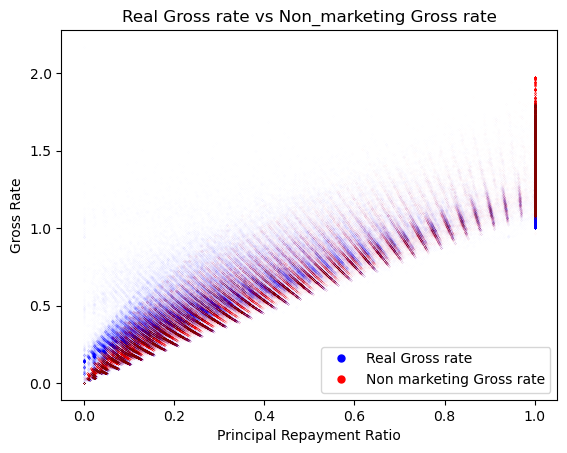

In [218]:
plt.close()
plt.plot(loan_data['target'],loan_data['real_rate'],label='Real Gross rate', marker='o', linestyle='', color='b',markersize=0.005,alpha=1)
plt.plot(loan_data['target'],loan_data['non_marketing_rate'],label='Non marketing Gross rate', marker='o', linestyle='', color='r',markersize=0.005)
plt.title('Real Gross rate vs Non_marketing Gross rate')
plt.xlabel('Principal Repayment Ratio')
plt.ylabel('Gross Rate')
plt.legend(
    loc='best', 
    markerscale=1000, 
)
plt.savefig('/Users/kbh/Downloads/lending club/Gross_rate_diff_Real_Non_marketing.png',dpi=400)
plt.show()

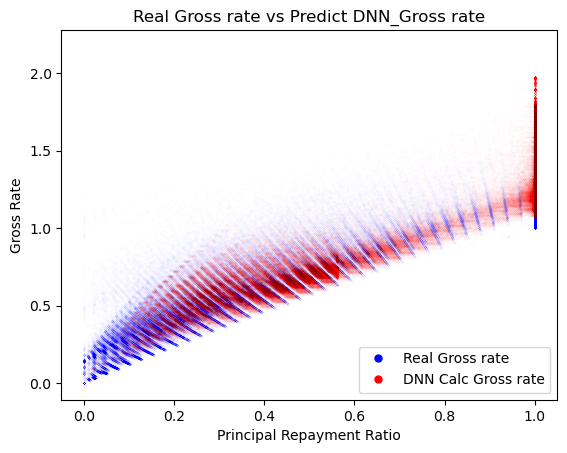

In [224]:
plt.close()
plt.plot(loan_data['target'],loan_data['real_rate'],label='Real Gross rate', marker='o', linestyle='', color='b',markersize=0.005,alpha=1)
plt.plot(loan_data['predict_target'],loan_data['predict_DNN_rate'],label='DNN Calc Gross rate', marker='o', linestyle='', color='r',markersize=0.005)
plt.title('Real Gross rate vs Predict DNN_Gross rate')
plt.xlabel('Principal Repayment Ratio')
plt.ylabel('Gross Rate')
plt.legend(
    loc='best', 
    markerscale=1000, 
)
# plt.savefig('/Users/kbh/Downloads/lending club/Gross_rate_diff_DNN.png',dpi=400)
plt.show()

In [36]:
from mpl_toolkits.mplot3d import Axes3D

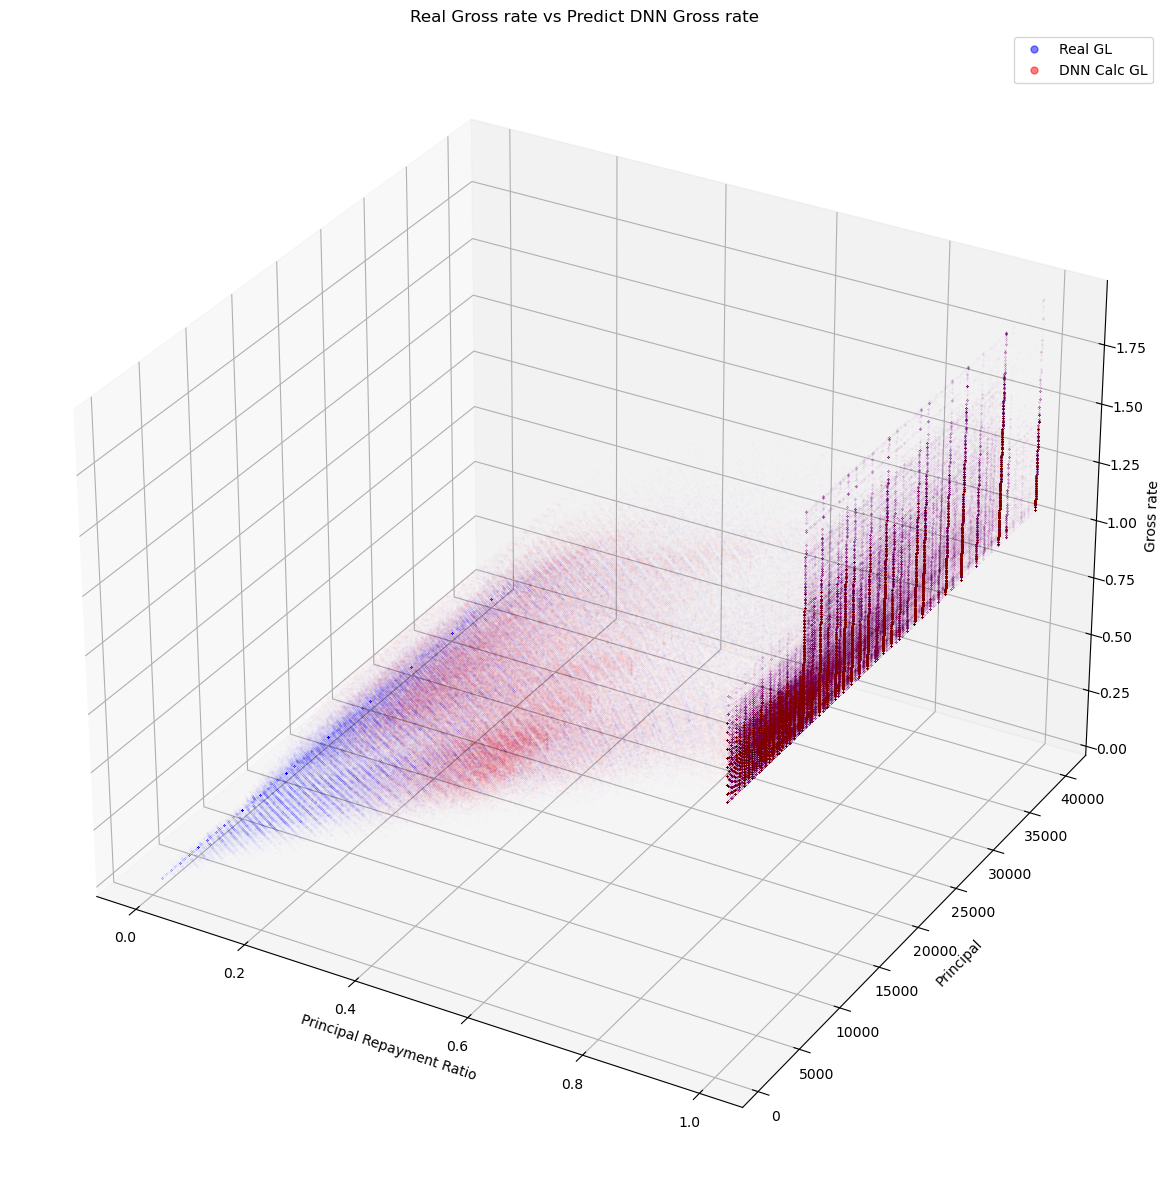

In [226]:
plt.close()
plt.ioff()
fig = plt.figure(figsize=(12 ,12))
ax = fig.add_subplot(111, projection='3d')
ax.plot(loan_data['target'],loan_data['funded_amnt'],loan_data['non_marketing_rate'], label='Real GL',color='b', marker='o', linestyle='', alpha=0.5, markersize=0.01)
ax.plot(loan_data['predict_target'], loan_data['funded_amnt'],loan_data['predict_DNN_rate'], label='DNN Calc GL',color='r', marker='o', linestyle='', alpha=0.5, markersize=0.01)
plt.title('Real Gross rate vs Predict DNN Gross rate')
plt.xlabel('Principal Repayment Ratio')
plt.ylabel("Principal")
ax.set_zlabel('Gross rate')
plt.legend(
    loc='best', 
    markerscale=500, 
)
plt.tight_layout()
# plt.savefig('/Users/kbh/Downloads/lending club/Gross_rate_diff_DNN_3d.png',dpi=400)
plt.show()

In [80]:
# loan_data.to_csv('/Users/kbh/Downloads/lending club/predict_DNN_loan_rate.csv')

In [112]:
loan_data.loc[loan_data['predict_target']>=0.8,'non_marketing_rate'].corr(loan_data.loc[loan_data['predict_target']>=0.8,'calc_rate'])

0.9947296210080838

In [228]:
loan_data['predict_DNN_rate'].mean()

1.1151489522393963

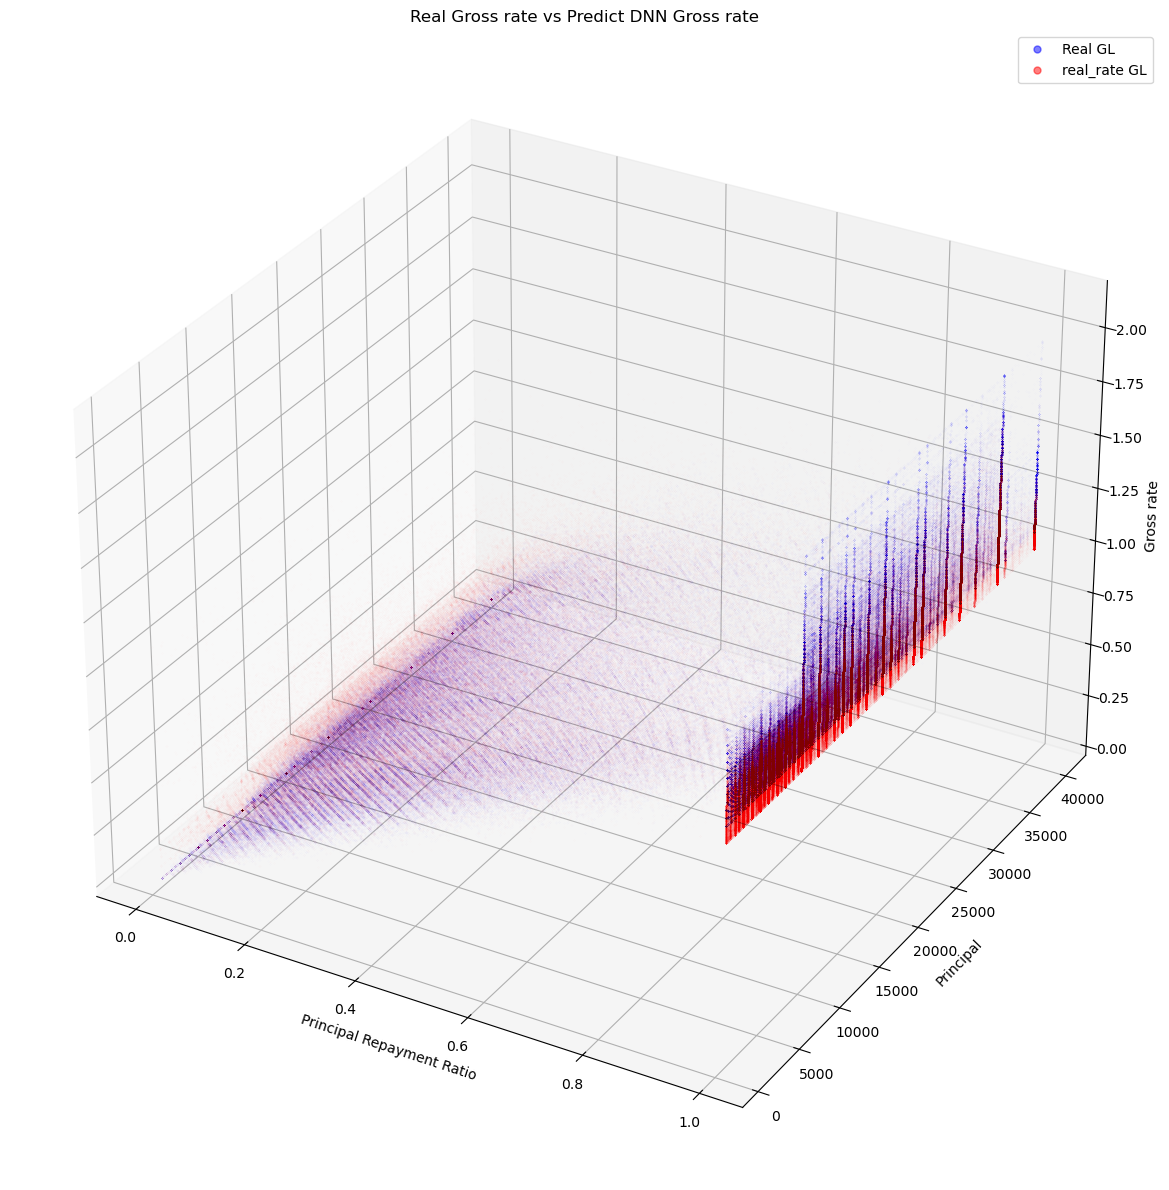

In [238]:
plt.close()
plt.ioff()
fig = plt.figure(figsize=(12 ,12))
ax = fig.add_subplot(111, projection='3d')
ax.plot(loan_data['target'],loan_data['funded_amnt'],loan_data['non_marketing_rate'], label='Real GL',color='b', marker='o', linestyle='', alpha=0.5, markersize=0.01)
ax.plot(loan_data['target'], loan_data['funded_amnt'],loan_data['real_rate'], label='real_rate GL',color='r', marker='o', linestyle='', alpha=0.5, markersize=0.01)
plt.title('Real Gross rate vs Predict DNN Gross rate')
plt.xlabel('Principal Repayment Ratio')
plt.ylabel("Principal")
ax.set_zlabel('Gross rate')
plt.legend(
    loc='best', 
    markerscale=500, 
)
plt.tight_layout()
plt.savefig('/Users/kbh/Downloads/lending club/Gross_rate_diff_nonmarket_3d.png',dpi=400)
plt.show()

In [25]:
import seaborn as sns

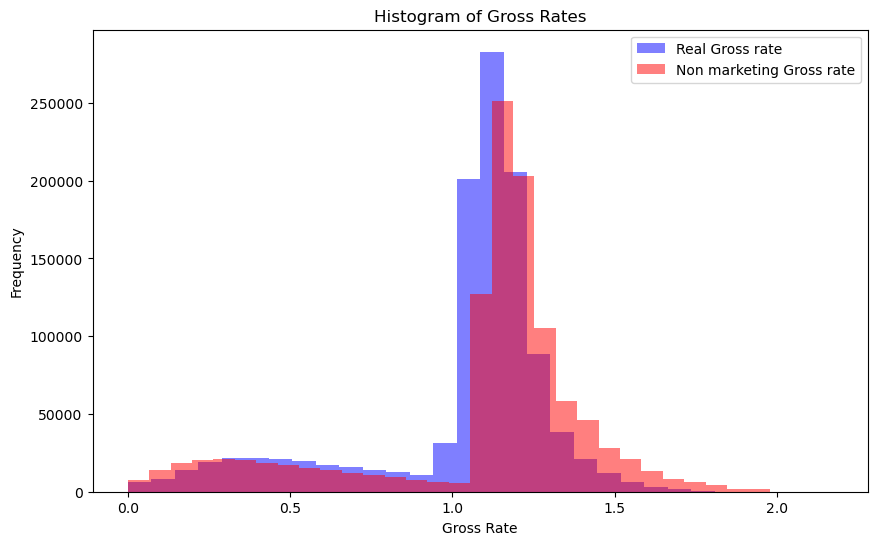

In [113]:
plt.close()
plt.ioff()
plt.figure(figsize=(10, 6))
plt.hist(loan_data['real_rate'], bins=30, alpha=0.5, label='Real Gross rate', color='blue')
plt.hist(loan_data['non_marketing_rate'], bins=30, alpha=0.5, label='Non marketing Gross rate', color='red')

plt.title('Histogram of Gross Rates')
plt.xlabel('Gross Rate')
plt.ylabel('Frequency')

plt.legend()
# plt.savefig('/Users/kbh/Downloads/lending club/Histogram of gross rate.png',dpi=400)
plt.show()

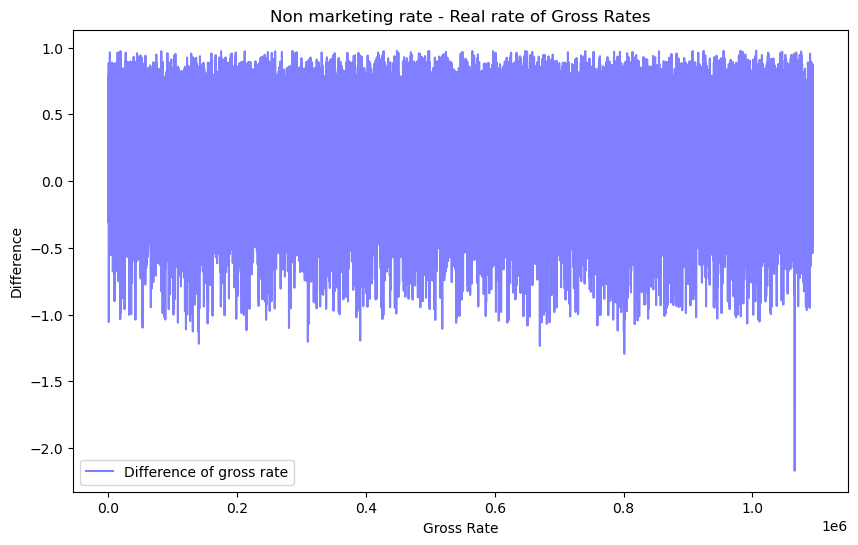

In [225]:
plt.close()
plt.ioff()
plt.figure(figsize=(10, 6))
plt.plot(loan_data['non_marketing_rate']-loan_data['real_rate'], alpha=0.5, label='Difference of gross rate', color='blue')

plt.title('Non marketing rate - Real rate of Gross Rates')
plt.xlabel('Gross Rate')
plt.ylabel('Difference')

plt.legend()
plt.savefig('/Users/kbh/Downloads/lending club/Difference of gross rate.png',dpi=400)
plt.show()

In [297]:
loan_data['real_rate'].mean()

1.0341932079717255

In [299]:
loan_data['non_marketing_rate'].mean()

1.0875587468336716

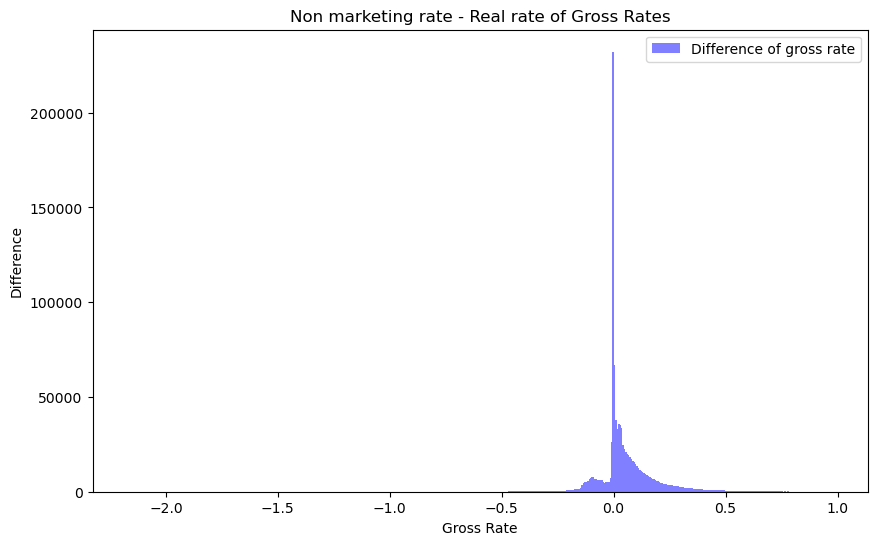

In [313]:
plt.close()
plt.ioff()
plt.figure(figsize=(10, 6))
plt.hist(loan_data['non_marketing_rate']-loan_data['real_rate'], bins=500,alpha=0.5, label='Difference of gross rate', color='blue')

plt.title('Non marketing rate - Real rate of Gross Rates')
plt.xlabel('Gross Rate')
plt.ylabel('Difference')

plt.legend()
plt.savefig('/Users/kbh/Downloads/lending club/Difference of gross rate.png',dpi=400)
plt.show()

In [227]:
loan_data.columns

Index(['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'sub_grade', 'emp_length', 'home_ownership',
       ...
       'result', 'return_total_pay', 'loan_rate', 'real_rate',
       'real_installment', 'original_result', 'calc_installment',
       'predict_DNN_rate', 'non_marketing_rate', 'predict_target'],
      dtype='object', length=128)

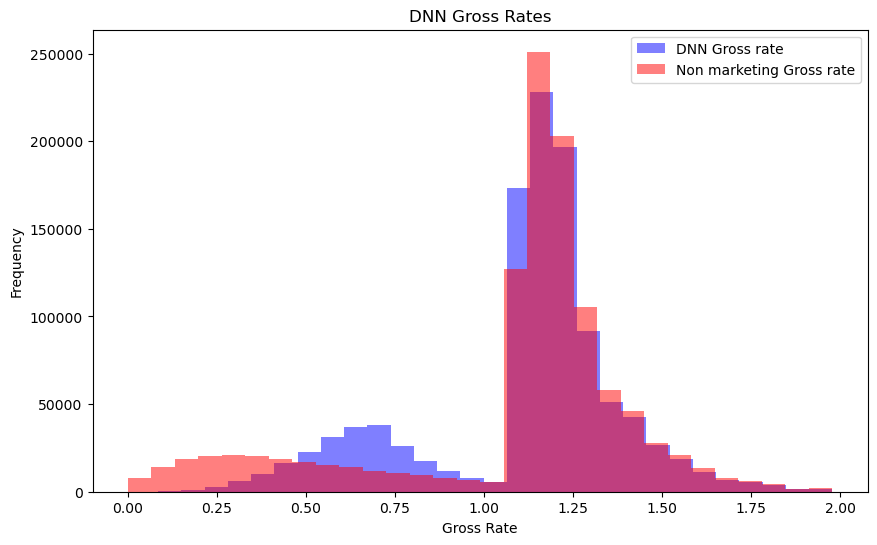

In [311]:
plt.close()
plt.ioff()
plt.figure(figsize=(10, 6))
plt.hist(loan_data['predict_DNN_rate'], bins=30, alpha=0.5, label='DNN Gross rate', color='blue')
# plt.hist(loan_data['real_rate'], bins=30, alpha=0.5, label='real Gross rate')
plt.hist(loan_data['non_marketing_rate'], bins=30, alpha=0.5, label='Non marketing Gross rate', color='red')

plt.title('DNN Gross Rates')
plt.xlabel('Gross Rate')
plt.ylabel('Frequency')

plt.legend()
# plt.savefig('/Users/kbh/Downloads/lending club/Histogram of DNN predict.png',dpi=400)
plt.show()

# ETF Bond 수익률

In [255]:
etf_bond_result=selected_etf_bond_rate(loan_data,etf_data,bond3yr,bond5yr)
loan_data=pandas.concat([loan_data,etf_bond_result],axis=1)
loan_data.head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,purpose,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,last_fico_range_high,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,debt_settlement_flag,target,result,return_total_pay,loan_rate,real_rate,real_installment,original_result,calc_installment,predict_DNN_rate,non_marketing_rate,predict_target,type,rate
0,124989905,6000.0000,6000.0000,6000.0000,36,7.9700,187.9400,4,2.0000,MORTGAGE,45000.0000,Verified,2017-12-01,Fully Paid,n,debt_consolidation,8.6700,1.0000,2005-09-01,755.0000,759.0000,0.0000,22.0000,14.0000,0.0000,3090.0000,14.0000,36.0000,w,0.0000,0.0000,6718.8400,6718.8400,6000.0000,718.8400,0.0000,0.0000,0.0000,2020-04,1835.0600,2020-04,764.0000,0.0000,0.0000,1.0000,Joint App,100500.0000,10.2000,Verified,0.0000,0.0000,50054.0000,1.0000,10.0000,3.0000,3.0000,3.0000,46964.0000,83.0000,1.0000,1.0000,3090.0000,64.0000,22100.0000,1.0000,0.0000,2.0000,4.0000,3850.0000,11910.0000,20.6000,0.0000,0.0000,147.0000,135.0000,12.0000,3.0000,1.0000,56.0000,37.0000,3.0000,33.0000,0.0000,1.0000,1.0000,1.0000,4.0000,28.0000,4.0000,7.0000,1.0000,14.0000,0.0000,0.0000,0.0000,4.0000,97.1000,0.0000,0.0000,0.0000,78611.0000,50054.0000,15000.0000,56511.0000,3926.0000,555.0000,559.0000,Sep-2005,0.0000,0.0000,10.0000,0.0000,10.0000,4.0000,1.0000,0.0000,N,1.0000,36,6732.0000,1.1276,1.1198,187.9400,36,187.0000,1.1220,1.1220,1.0000,Bond,1.0190
1,84253847,23200.0000,23200.0000,23200.0000,60,24.9900,680.8200,23,10.0000,MORTGAGE,110000.0000,Verified,2016-07-01,Charged Off,n,debt_consolidation,34.7000,1.0000,1993-05-01,670.0000,674.0000,1.0000,10.0000,24.0000,0.0000,16909.0000,55.9000,60.0000,f,0.0000,0.0000,8599.6800,8599.6800,1030.4300,2309.2500,0.0000,5260.0000,946.8000,2016-12,680.8200,2019-02,639.0000,0.0000,0.0000,1.0000,Individual,0.0000,0.0000,0,0.0000,0.0000,606327.0000,1.0000,10.0000,1.0000,2.0000,10.0000,277552.0000,90.0000,4.0000,6.0000,4698.0000,85.0000,30255.0000,4.0000,3.0000,7.0000,8.0000,25264.0000,6014.0000,70.4000,0.0000,0.0000,126.0000,277.0000,6.0000,6.0000,2.0000,7.0000,10.0000,0.0000,10.0000,0.0000,8.0000,10.0000,8.0000,14.0000,36.0000,12.0000,22.0000,10.0000,24.0000,0.0000,0.0000,0.0000,5.0000,94.8000,37.5000,0.0000,0.0000,650914.0000,294461.0000,20300.0000,291465.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,Y,0.0444,60,40800.0000,0.1467,0.3

In [257]:
# loan_data.to_csv('/Users/kbh/Downloads/lending club/DNN_final_rate.csv',index=False)

In [261]:
def select_good_rate(loan_data,target:str) : 
    loans=loan_data
    loans['final_type'] = numpy.where(
        loans[target] > loans['rate'],
        'Loan',
        loans['type']
    )
    loans['selected_rate'] = numpy.where(
        loans[target] > loans['rate'],
        loans[target],
        loans['rate']
    )
    loans=loans.reset_index(drop=True)
    return loans

In [263]:
final_revenue=select_good_rate(loan_data,'predict_DNN_rate')

In [319]:
final_original=select_good_rate(loan_data,'non_marketing_rate')

In [267]:
# final_revenue.to_csv('/Users/kbh/Downloads/lending club/DNN_final_rate.csv',index=False)

In [273]:
final_revenue.head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,purpose,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,last_fico_range_high,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,debt_settlement_flag,target,result,return_total_pay,loan_rate,real_rate,real_installment,original_result,calc_installment,predict_DNN_rate,non_marketing_rate,predict_target,type,rate,final_type,selected_rate
0,124989905,6000.0000,6000.0000,6000.0000,36,7.9700,187.9400,4,2.0000,MORTGAGE,45000.0000,Verified,2017-12-01,Fully Paid,n,debt_consolidation,8.6700,1.0000,2005-09-01,755.0000,759.0000,0.0000,22.0000,14.0000,0.0000,3090.0000,14.0000,36.0000,w,0.0000,0.0000,6718.8400,6718.8400,6000.0000,718.8400,0.0000,0.0000,0.0000,2020-04,1835.0600,2020-04,764.0000,0.0000,0.0000,1.0000,Joint App,100500.0000,10.2000,Verified,0.0000,0.0000,50054.0000,1.0000,10.0000,3.0000,3.0000,3.0000,46964.0000,83.0000,1.0000,1.0000,3090.0000,64.0000,22100.0000,1.0000,0.0000,2.0000,4.0000,3850.0000,11910.0000,20.6000,0.0000,0.0000,147.0000,135.0000,12.0000,3.0000,1.0000,56.0000,37.0000,3.0000,33.0000,0.0000,1.0000,1.0000,1.0000,4.0000,28.0000,4.0000,7.0000,1.0000,14.0000,0.0000,0.0000,0.0000,4.0000,97.1000,0.0000,0.0000,0.0000,78611.0000,50054.0000,15000.0000,56511.0000,3926.0000,555.0000,559.0000,Sep-2005,0.0000,0.0000,10.0000,0.0000,10.0000,4.0000,1.0000,0.0000,N,1.0000,36,6732.0000,1.1276,1.1198,187.9400,36,187.0000,1.1220,1.1220,1.0000,Bond,1.0190,Loan,1.1220
1,84253847,23200.0000,23200.0000,23200.0000,60,24.9900,680.8200,23,10.0000,MORTGAGE,110000.0000,Verified,2016-07-01,Charged Off,n,debt_consolidation,34.7000,1.0000,1993-05-01,670.0000,674.0000,1.0000,10.0000,24.0000,0.0000,16909.0000,55.9000,60.0000,f,0.0000,0.0000,8599.6800,8599.6800,1030.4300,2309.2500,0.0000,5260.0000,946.8000,2016-12,680.8200,2019-02,639.0000,0.0000,0.0000,1.0000,Individual,0.0000,0.0000,0,0.0000,0.0000,606327.0000,1.0000,10.0000,1.0000,2.0000,10.0000,277552.0000,90.0000,4.0000,6.0000,4698.0000,85.0000,30255.0000,4.0000,3.0000,7.0000,8.0000,25264.0000,6014.0000,70.4000,0.0000,0.0000,126.0000,277.0000,6.0000,6.0000,2.0000,7.0000,10.0000,0.0000,10.0000,0.0000,8.0000,10.0000,8.0000,14.0000,36.0000,12.0000,22.0000,10.0000,24.0000,0.0000,0.0000,0.0000,5.0000,94.8000,37.5000,0.0000,0.0000,650914.0000,294461.0000,20300.0000,291465.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0

In [321]:
final_original['selected_rate'].mean()

1.1997436005424822

In [283]:
final_revenue['selected_rate'].mean()

1.1931571119047655